# CS729 Question 3: Effect of Gradient Clipping Norm in DP-SGD

In this notebook, we study the effect of the clipping norm $C$ in DP-SGD on the MNIST dataset using a feed-forward neural network.

We compare the following clipping norms:

$
C \in \{0.1,\; 10.0\}
$

while keeping the **noise multiplier** and **batch size** fixed.

The goal is to understand how the clipping norm affects optimization and convergence in differentially private training.

In [1]:
!pip install -q opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.5 MB/s eta 0:00:00a 0:00:01


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from opacus import PrivacyEngine
from opacus.accountants.utils import get_noise_multiplier

## Experimental Design

We keep the overall setup fixed and change only the clipping norm $C$.

### Fixed choices
- Dataset: MNIST
- Model: Feed-forward neural network
- Optimizer: SGD
- Accountant: RDP
- Batch size: fixed
- Noise multiplier: fixed across both runs

### What changes
- The clipping norm $C$ is changed between:
  - $C = 0.1$
  - $C = 10.0$

To make the clipping implementation explicit, we use:

- **flat clipping** (`clipping="flat"`) as the clipping rule
- **ghost clipping** (`grad_sample_mode="ghost"`) as the memory-efficient implementation

In [3]:
SEED = 42

BATCH_SIZE = 64
TEST_BATCH_SIZE = 1024
EPOCHS = 10

LR = 0.1
MOMENTUM = 0.0

DELTA = 1e-5
ACCOUNTANT = "rdp"

CLIP_NORMS = [0.1, 10.0]

# We calibrate one fixed noise multiplier once, then reuse it for both C values.
TARGET_EPSILON_FOR_FIXED_SIGMA = 5.0

CLIPPING_MODE = "flat"
GRAD_SAMPLE_MODE = "ghost"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(SEED)

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

def make_train_loader(seed: int = SEED, shuffle: bool = True):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

def make_test_loader():
    return DataLoader(
        test_dataset,
        batch_size=TEST_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

base_train_loader = make_train_loader()
test_loader = make_test_loader()

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Batches per epoch:", len(base_train_loader))

100%|██████████| 9.91M/9.91M [00:00<00:00, 33.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.86MB/s]

Training samples: 60000
Test samples: 10000
Batches per epoch: 938


## Model

We use a simple feed-forward neural network, consistent with the assignment requirement.

In [6]:
class FeedForwardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

def build_model():
    return FeedForwardNet().to(DEVICE)

def build_optimizer(model):
    return optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

## Clipping Implementation Used

In this notebook, I use:

- **Flat clipping** as the clipping rule
- **Ghost clipping** as the memory-efficient implementation in Opacus

### Why this reduces memory usage

Naively, DP-SGD needs per-sample gradients, which has memory complexity $O(BP)$, where:
- $B$ = batch size
- $P$ = number of trainable parameters

Ghost clipping avoids explicitly materializing per-sample gradients for supported layers. For linear layers, it computes per-sample gradient norms from activations and backpropagated activations instead of storing the full per-sample gradient tensor.

For a feed-forward network built from linear layers, this reduces the additional memory overhead to approximately:

$
O(BL)
$

where $L$ is the number of layers.

Thus, ghost clipping is much more memory efficient than the naive $O(BP)$ approach.

In [8]:
criterion_eval = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, criterion_private):
    model.train()
    iteration_losses = []
    running_loss = 0.0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion_private(logits, y)
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        iteration_losses.append(loss_value)
        running_loss += loss_value

    epoch_loss = running_loss / len(loader)
    return iteration_losses, epoch_loss

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion_eval(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = 100.0 * correct / total
    return avg_loss, acc

## Fixed Noise Multiplier

The question asks us to keep the noise multiplier fixed while varying the clipping norm.

To do this in a principled way, we first calibrate a single noise multiplier using the RDP accountant for a target privacy budget, and then reuse that same noise multiplier for both clipping norms.

In [9]:
sample_rate = 1.0 / len(base_train_loader)

FIXED_NOISE_MULTIPLIER = get_noise_multiplier(
    target_epsilon=TARGET_EPSILON_FOR_FIXED_SIGMA,
    target_delta=DELTA,
    sample_rate=sample_rate,
    epochs=EPOCHS,
    accountant=ACCOUNTANT,
)

print("Fixed noise multiplier used for both runs:", FIXED_NOISE_MULTIPLIER)

/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Fixed noise multiplier used for both runs: 0.538330078125


## DP-SGD Training Function

We now run the same DP-SGD experiment twice:

- once with $C = 0.1$
- once with $C = 10.0$

The only thing that changes is `max_grad_norm`.

In [10]:
def run_dp_experiment_for_clip_norm(clip_norm: float, seed: int = SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_optimizer(model)
    criterion = nn.CrossEntropyLoss()

    train_loader = make_train_loader(seed=seed, shuffle=True)
    test_loader = make_test_loader()

    privacy_engine = PrivacyEngine(accountant=ACCOUNTANT)

    model, optimizer, criterion_private, private_train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        criterion=criterion,
        data_loader=train_loader,
        noise_multiplier=FIXED_NOISE_MULTIPLIER,
        max_grad_norm=clip_norm,
        clipping=CLIPPING_MODE,
        grad_sample_mode=GRAD_SAMPLE_MODE,
    )

    metrics = {
        "clip_norm": clip_norm,
        "iteration_losses": [],
        "epoch_losses": [],
        "epsilons": [],
        "test_losses": [],
        "test_accuracies": [],
    }

    for epoch in range(1, EPOCHS + 1):
        iter_losses, epoch_loss = train_one_epoch(
            model,
            private_train_loader,
            optimizer,
            criterion_private,
        )

        test_loss, test_acc = evaluate(model, test_loader)
        eps_spent = privacy_engine.get_epsilon(delta=DELTA)

        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(eps_spent)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)

        print(
            f"[C = {clip_norm}] Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Epsilon Spent: {eps_spent:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

    metrics["final_epsilon"] = metrics["epsilons"][-1]
    metrics["final_test_loss"] = metrics["test_losses"][-1]
    metrics["final_test_accuracy"] = metrics["test_accuracies"][-1]

    return metrics

In [11]:
results = {}

for clip_norm in CLIP_NORMS:
    print("=" * 80)
    print(f"Running DP-SGD with clipping norm C = {clip_norm}")
    results[clip_norm] = run_dp_experiment_for_clip_norm(clip_norm)

print("All Question 3 experiments completed.")

Running DP-SGD with clipping norm C = 0.1


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[C = 0.1] Epoch 01/10 | Train Loss: 1.9564 | Epsilon Spent: 3.5517 | Test Loss: 1.4831 | Test Acc: 69.24%
[C = 0.1] Epoch 02/10 | Train Loss: 1.1436 | Epsilon Spent: 3.8305 | Test Loss: 0.8897 | Test Acc: 73.42%
[C = 0.1] Epoch 03/10 | Train Loss: 0.7919 | Epsilon Spent: 4.0340 | Test Loss: 0.6895 | Test Acc: 75.57%
[C = 0.1] Epoch 04/10 | Train Loss: 0.6626 | Epsilon Spent: 4.2119 | Test Loss: 0.6060 | Test Acc: 79.23%
[C = 0.1] Epoch 05/10 | Train Loss: 0.6067 | Epsilon Spent: 4.3624 | Test Loss: 0.5696 | Test Acc: 81.40%
[C = 0.1] Epoch 06/10 | Train Loss: 0.5808 | Epsilon Spent: 4.5108 | Test Loss: 0.5239 | Test Acc: 84.40%
[C = 0.1] Epoch 07/10 | Train Loss: 0.5430 | Epsilon Spent: 4.6347 | Test Loss: 0.4988 | Test Acc: 86.10%
[C = 0.1] Epoch 08/10 | Train Loss: 0.5268 | Epsilon Spent: 4.7586 | Test Loss: 0.4899 | Test Acc: 87.13%
[C = 0.1] Epoch 09/10 | Train Loss: 0.5112 | Epsilon Spent: 4.8824 | Test Loss: 0.4901 | Test Acc: 87.74%
[C = 0.1] Epoch 10/10 | Train Loss: 0.5401 | E

## Plot: Iterations vs Training Loss

The assignment asks for a plot of Number of Iterations (Epoch × Batches) vs Training Loss for each clipping norm.

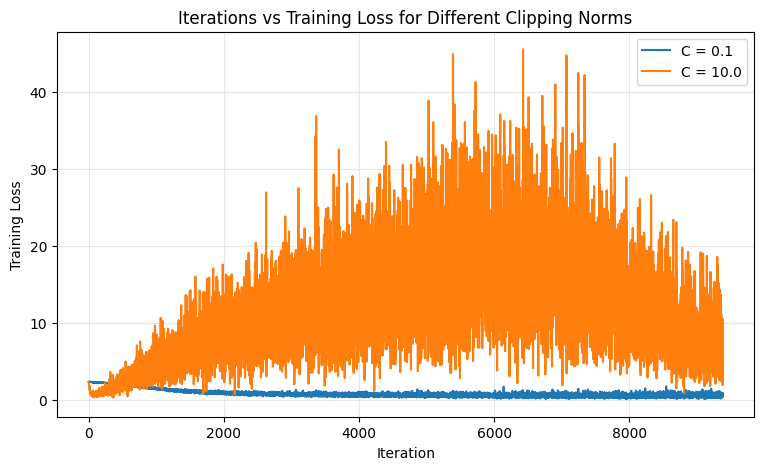

In [12]:
plt.figure(figsize=(9, 5))

for clip_norm, res in results.items():
    iterations = np.arange(1, len(res["iteration_losses"]) + 1)
    plt.plot(iterations, res["iteration_losses"], label=f"C = {clip_norm}")

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Iterations vs Training Loss for Different Clipping Norms")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary Table

In [13]:
summary_rows = []

for clip_norm, res in results.items():
    summary_rows.append({
        "clip_norm": clip_norm,
        "noise_multiplier": FIXED_NOISE_MULTIPLIER,
        "final_epsilon": res["final_epsilon"],
        "final_test_loss": res["final_test_loss"],
        "final_test_accuracy": res["final_test_accuracy"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("clip_norm")
summary_df

,clip_norm,noise_multiplier,final_epsilon,final_test_loss,final_test_accuracy
0,0.1,0.53833,4.990624,0.497063,88.36
1,10.0,0.53833,4.990624,6.647723,64.02


## Observations

In DP-SGD, each per-sample gradient is clipped to norm at most $C$, and Gaussian noise is added proportional to the clipping norm. For a fixed noise multiplier $\sigma$, the effective noise scale is proportional to $\sigma 
C$.

Thus, changing $C$ creates a trade-off:

- A **smaller** clipping norm increases clipping bias because more gradients are truncated.
- A **larger** clipping norm reduces clipping bias, but also increases the absolute magnitude of injected noise.

In our experiment, with batch size and noise multiplier fixed, the run with $C = 0.1$ converged much better than the run with $C = 10.0$. The training loss for $C = 0.1$ decreases steadily, and the final test accuracy is significantly higher. In contrast, the run with $C = 10.0$ shows unstable training and much worse final loss/accuracy.

This suggests that, under our chosen setup, increasing $C$ made the added DP noise too large relative to the learning signal. Therefore, although very small clipping norms can sometimes hurt optimization, in this experiment the smallest clipping norm $C = 0.1$ **did converge**, whereas $C = 10.0$ performed substantially worse.

## Final Answer for Part (a)

I used **flat clipping** in Opacus as the clipping rule and **ghost clipping** as the memory-efficient implementation:
- `clipping="flat"`
- `grad_sample_mode="ghost"`

Naively, DP-SGD requires storing per-sample gradients for all parameters, which has memory complexity $O(BP)$, where $B$ is the batch size and $P$ is the number of trainable parameters.

Ghost clipping avoids explicitly materializing the full per-sample gradient tensors for supported layers. Instead, it computes the quantities needed for clipping from intermediate activations and backpropagated activations. Hence, the additional memory overhead no longer scales like $O(BP)$, and is much smaller in practice, scaling with batch size and layer-wise intermediate quantities rather than the full parameter-space per-sample gradients.